# v08 results scorecard

A reader for the **v08** experiments (assay-filtered + species-stratified), printing metrics side-by-side with **v07** predecessors.

## Two reference frames (MMD and R²)

| Frame | What it measures | Where computed |
| ----- | ---------------- | -------------- |
| **Raw refs** (mixed for IMPACT) | MMD floor/ceiling on **raw** control/treated; model MMD on **decoded imputed vs raw treated**. R² floor/ceiling on **raw** means; model R² uses decoded imputed vs raw treated. | `extended_metrics.csv` via `./hub metrics` |
| **Decoded refs** (AE round-trip on control/treated) | MMD: `mmd_ae_recon_floor`, `mmd_decoded_ceiling`, `frac_gap_closed_decoded`. R²: round-trip control/treated means, `frac_r2_closed_decoded`. | §2 below — CellOT env, `decoded_frame_metrics.py` |

Raw `frac_gap_closed` can go **negative on IMPACT** even when transport helps (AE round-trip tax — see `docs/concepts/AE round-trip tax.md`). Always read **both** frames.

**§1** — CSV-only scorecard (pandas). **§2** — decoded frame (subprocess → CellOT). Add rows to `MODELS` for new runs.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

REPO = Path("/n/holylabs/mooney_lab/Lab/junyizhou/speciesOT")
RESULTS = REPO / "cellot/cellot_gpu/results"
EVALPREFIX = "evals_ood_data_space"
NCELLS = 80

# (label, results_subdir). Add atlas CD8 etc. here once trained.
MODELS = [
    ("m1 v07 IMPACT", "hvg_pearson_residuals_m1_ood/impact_cellot"),
    ("m1 v07 scGen",  "hvg_pearson_residuals_m1_ood/scgen"),
    ("m1 v08 IMPACT", "hvg_pearson_residuals_m1_v08_ood/impact_cellot"),
    ("m1 v08 scGen",  "hvg_pearson_residuals_m1_v08_ood/scgen"),
    ("m2 v07 IMPACT", "hvg_pearson_residuals_m2_ood/impact_cellot"),
    ("m2 v07 scGen",  "hvg_pearson_residuals_m2_ood/scgen"),
    ("m2 v08 IMPACT", "hvg_pearson_residuals_m2_v08_ood/impact_cellot"),
    ("m2 v08 scGen",  "hvg_pearson_residuals_m2_v08_ood/scgen"),
    # Uncapped FULL-atlas, CD8 holdout: v07 (no assay filter) vs v08 (assay-filtered)
    ("atlas-CD8 v07 IMPACT", "hvg_pearson_residuals_a_ood_uncapped/impact_cellot"),
    ("atlas-CD8 v07 scGen",  "hvg_pearson_residuals_a_ood_uncapped/scgen"),
    ("atlas-CD8 v08 IMPACT", "hvg_pearson_residuals_a_uncapped_v08_ood/impact_cellot"),
    ("atlas-CD8 v08 scGen",  "hvg_pearson_residuals_a_uncapped_v08_ood/scgen"),
]


def _r2_mmd(eval_dir):
    """R2 (= squared r2-means) and MMD at ncells=80 from evals.csv; (nan, nan, status)."""
    p = eval_dir / "evals.csv"
    if not p.exists():
        return np.nan, np.nan, "pending (no evals.csv)"
    df = pd.read_csv(p)
    sub = df[(df["nfeatures"] == "all") & (df["ncells"] == NCELLS)]
    if sub.empty:
        return np.nan, np.nan, "evals.csv has no ncells=80"
    r2 = (sub.loc[sub["metric"] == "r2-means", "value"].astype(float) ** 2).mean()
    mmd = sub.loc[sub["metric"] == "mmd", "value"].astype(float).mean()
    return r2, mmd, "ok"


_EXT_KEYS = ("mmd_floor", "mmd_ceiling", "gap_above_floor", "frac_gap_closed", "mean_js",
             "r2_self", "r2_identity", "frac_r2_closed")


def _extended(eval_dir):
    """Extended metrics (MMD + R2 floor/ceiling) from extended_metrics.csv (max ncells)."""
    p = eval_dir / "extended_metrics.csv"
    if not p.exists():
        return {k: np.nan for k in _EXT_KEYS}
    df = pd.read_csv(p)
    row = df.loc[df["ncells"].idxmax()]
    return {k: (float(row[k]) if k in df.columns and pd.notna(row[k]) else np.nan)
            for k in _EXT_KEYS}


rows = []
for label, sub in MODELS:
    eval_dir = RESULTS / sub / EVALPREFIX
    r2, mmd, status = _r2_mmd(eval_dir)
    ext = _extended(eval_dir)
    rows.append({"model": label, "R2": r2, "MMD": mmd, **ext, "status": status})

scorecard = pd.DataFrame(rows)
# Raw-reference sidecar columns (mixed frame for IMPACT model MMD/R²)
scorecard = scorecard.rename(columns={
    "frac_gap_closed": "frac_gap_closed_raw",
    "frac_r2_closed": "frac_r2_closed_raw",
})
numcols = ["R2", "MMD", "mmd_floor", "mmd_ceiling", "gap_above_floor", "frac_gap_closed_raw",
           "mean_js", "r2_self", "r2_identity", "frac_r2_closed_raw"]
scorecard[numcols] = scorecard[numcols].astype(float).round(4)
scorecard.to_csv(REPO / "speciesOT/baseline/analysis/v08_scorecard_raw.csv", index=False)
scorecard

,model,R2,MMD,mmd_floor,mmd_ceiling,gap_above_floor,frac_gap_closed_raw,mean_js,r2_self,r2_identity,frac_r2_closed_raw,status
0,m1 v07 IMPACT,0.9407,0.1375,0.0238,0.0902,0.1134,-0.7072,0.4653,0.9871,0.4343,0.9216,ok
1,m1 v07 scGen,0.9094,0.1677,0.0238,0.0902,0.1430,-1.1524,0.4901,0.9871,0.4343,0.8702,ok
2,m1 v08 IMPACT,0.9188,0.1035,0.0236,0.1087,0.0800,0.0608,0.4492,0.9917,0.5542,0.8316,ok
3,m1 v08 scGen,0.9270,0.1737,0.0236,0.1087,0.1497,-0.7588,0.5023,0.9917,0.5542,0.8571,ok
4,m2 v07 IMPACT,0.9301,0.1080,0.0237,0.0867,0.0840,-0.3328,0.4507,0.9889,0.4570,0.9041,ok
5,m2 v07 scGen,0.8916,0.1458,0.0237,0.0867,0.1224,-0.9429,0.4736,0.9889,0.4570,0.8263,ok
6,m2 v08 IMPACT,0.9231,0.1146,0.0233,0.1062,0.0935,-0.1276,0.4515,0.9924,0.5590,0.8539,ok
7,m2 v08 scGen,0.9443,0.1610,0.0233,0.1062,0.1389,-0.6747,0.4850,0.9924,0.5590,0.8989,ok
8,atlas-CD8 v07 IMPACT,0.8479,0.0513,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ok
9,atlas-CD8 v07 scGen,0.9321,0.1163,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ok


## §2 — Decoded reference frame (CellOT)

Round-trips **control** and **treated** through the scGen AE (`decode∘encode`), then recomputes floor/ceiling for MMD and R². Requires the CellOT conda env (torch + `load_projectors`). Regenerates `eval_clouds.npz` if missing.

**Not yet in `./hub metrics`** — outputs `decoded_frame_metrics.csv` next to `extended_metrics.csv`.

In [5]:
import os
import subprocess

CELLOT_PY = "/n/home01/jzhou1125/.conda/envs/CellOT/bin/python"
CELL_GPU = REPO / "cellot/cellot_gpu"

_DEC_KEYS = (
    "mmd_ae_recon_floor", "mmd_decoded_ceiling", "gap_above_ae_recon",
    "frac_gap_closed_decoded", "r2_self_dec", "r2_identity_dec",
    "frac_r2_closed_decoded",
)


def _cellot_outdir(results_subdir):
    """Scripts run with cwd=cellot_gpu; model dirs live under ./results/."""
    return f"./results/{results_subdir}"


def _ensure_clouds(results_subdir):
    eval_dir = RESULTS / results_subdir / EVALPREFIX
    npz = eval_dir / "eval_clouds.npz"
    if npz.exists():
        return
    subprocess.run(
        [CELLOT_PY, "scripts/dump_eval_clouds.py", "--outdir", _cellot_outdir(results_subdir),
         "--setting", "ood", "--where", "data_space", "--embedding", "ae",
         "--evalprefix", EVALPREFIX],
        cwd=str(CELL_GPU), env={**os.environ, "PYTHONPATH": str(CELL_GPU)}, check=True,
    )


def _decoded(results_subdir):
    eval_dir = RESULTS / results_subdir / EVALPREFIX
    sidecar = eval_dir / "decoded_frame_metrics.csv"
    if not sidecar.exists():
        _ensure_clouds(results_subdir)
        subprocess.run(
            [CELLOT_PY, "scripts/decoded_frame_metrics.py", "--outdir", _cellot_outdir(results_subdir),
             "--setting", "ood", "--where", "data_space", "--embedding", "ae",
             "--evalprefix", EVALPREFIX],
            cwd=str(CELL_GPU), env={**os.environ, "PYTHONPATH": str(CELL_GPU)}, check=True,
        )
    df = pd.read_csv(sidecar)
    row = df.loc[df["ncells"].idxmax()]
    return {k: (float(row[k]) if k in df.columns and pd.notna(row[k]) else np.nan)
            for k in _DEC_KEYS}


dec_rows = []
for label, sub in MODELS:
    eval_dir = RESULTS / sub / EVALPREFIX
    if not (eval_dir / "evals.csv").exists():
        dec_rows.append({"model": label, **{k: np.nan for k in _DEC_KEYS}, "dec_status": "pending"})
        continue
    try:
        dec_rows.append({"model": label, **_decoded(sub), "dec_status": "ok"})
    except subprocess.CalledProcessError as exc:
        dec_rows.append({"model": label, **{k: np.nan for k in _DEC_KEYS},
                         "dec_status": f"failed ({exc.returncode})"})

decoded = pd.DataFrame(dec_rows)
dual = scorecard.merge(decoded, on="model", how="left")
dual_cols = [
    "model", "R2", "MMD",
    "frac_gap_closed_raw", "frac_gap_closed_decoded",
    "frac_r2_closed_raw", "frac_r2_closed_decoded",
    "mmd_floor", "mmd_ae_recon_floor", "mmd_ceiling", "mmd_decoded_ceiling",
    "r2_self", "r2_self_dec", "r2_identity", "r2_identity_dec",
    "gap_above_floor", "gap_above_ae_recon", "mean_js", "status", "dec_status",
]
dual = dual[dual_cols]
num = dual.select_dtypes(include="number").columns
dual[num] = dual[num].astype(float).round(4)
dual.to_csv(REPO / "speciesOT/baseline/analysis/v08_scorecard_dual.csv", index=False)
dual

[decoded-frame] loading clouds for results/hvg_pearson_residuals_m1_ood/impact_cellot ...
[decoded-frame] loading AE from results/hvg_pearson_residuals_m1_ood/model-scgen ...
[decoded-frame] computing decoded MMD references ...
 ncells  mmd_model  mmd_ae_recon_floor  mmd_decoded_ceiling  gap_above_ae_recon  frac_gap_closed_decoded  r2_model_dec  r2_self_dec  r2_identity_dec  frac_r2_closed_decoded
     30     0.1740              0.1135               0.2965              0.0605                   0.6693        0.9397       0.9965           0.4735                  0.8914
     50     0.1496              0.0865               0.2696              0.0630                   0.6557        0.9397       0.9965           0.4735                  0.8914
     80     0.1372              0.0733               0.2596              0.0639                   0.6569        0.9397       0.9965           0.4735                  0.8914
[decoded-frame] wrote results/hvg_pearson_residuals_m1_ood/impact_cellot/evals_o

Traceback (most recent call last):
  File "/n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/cellot/cellot_gpu/scripts/decoded_frame_metrics.py", line 168, in <module>
    main()
  File "/n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/cellot/cellot_gpu/scripts/decoded_frame_metrics.py", line 129, in main
    mmd_model = compute_mmd_two_sample(imputed, treated, **kw)
  File "/n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/cellot/cellot_gpu/cellot/losses/mmd.py", line 88, in compute_mmd_two_sample
    mmd = float(np.mean([mmd_distance(A[idx_a], B[idx_b], g) for g in gammas]))
  File "/n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/cellot/cellot_gpu/cellot/losses/mmd.py", line 88, in <listcomp>
    mmd = float(np.mean([mmd_distance(A[idx_a], B[idx_b], g) for g in gammas]))
  File "/n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/cellot/cellot_gpu/cellot/losses/mmd.py", line 7, in mmd_distance
    xy = rbf_kernel(x, y, gamma)
  File "/n/home01/jzhou1125/.conda/envs/CellOT/lib/python3.9/site-packag

[dump-clouds] reconstructing control + treated for results/hvg_pearson_residuals_a_ood_uncapped/scgen ...
[dump-clouds] reading imputed.h5ad ...
[dump-clouds] control (767, 1000)  treated (731, 1000)  imputed (767, 1000)  genes 1000
[dump-clouds] wrote results/hvg_pearson_residuals_a_ood_uncapped/scgen/evals_ood_data_space/eval_clouds.npz
[decoded-frame] loading clouds for results/hvg_pearson_residuals_a_ood_uncapped/scgen ...
[decoded-frame] loading AE from results/hvg_pearson_residuals_a_ood_uncapped/model-scgen ...
[decoded-frame] computing decoded MMD references ...
 ncells  mmd_model  mmd_ae_recon_floor  mmd_decoded_ceiling  gap_above_ae_recon  frac_gap_closed_decoded  r2_model_dec  r2_self_dec  r2_identity_dec  frac_r2_closed_decoded
     30     0.1474              0.1524               0.2064             -0.0050                   1.0934        0.9569       0.9994           0.5568                  0.9040
     50     0.1255              0.1250               0.1856              0.00

,model,R2,MMD,frac_gap_closed_raw,frac_gap_closed_decoded,frac_r2_closed_raw,frac_r2_closed_decoded,mmd_floor,mmd_ae_recon_floor,mmd_ceiling,mmd_decoded_ceiling,r2_self,r2_self_dec,r2_identity,r2_identity_dec,gap_above_floor,gap_above_ae_recon,mean_js,status,dec_status
0,m1 v07 IMPACT,0.9407,0.1375,-0.7072,0.6569,0.9216,0.8914,0.0238,0.0733,0.0902,0.2596,0.9871,0.9965,0.4343,0.4735,0.1134,0.0639,0.4653,ok,ok
1,m1 v07 scGen,0.9094,0.1677,-1.1524,0.4981,0.8702,0.8409,0.0238,0.0733,0.0902,0.2596,0.9871,0.9965,0.4343,0.4735,0.1430,0.0935,0.4901,ok,ok
2,m1 v08 IMPACT,0.9188,0.1035,0.0608,0.8974,0.8316,0.8210,0.0236,0.0805,0.1087,0.3057,0.9917,0.9976,0.5542,0.5779,0.0800,0.0231,0.4492,ok,ok
3,m1 v08 scGen,0.9270,0.1737,-0.7588,0.5875,0.8571,0.8567,0.0236,0.0805,0.1087,0.3057,0.9917,0.9976,0.5542,0.5779,0.1497,0.0929,0.5023,ok,ok
4,m2 v07 IMPACT,0.9301,0.1080,-0.3328,0.7783,0.9041,0.8972,0.0237,0.0679,0.0867,0.2473,0.9889,0.9973,0.4570,0.4831,0.0840,0.0398,0.4507,ok,ok
5,m2 v07 scGen,0.8916,0.1458,-0.9429,0.5640,0.8263,0.8177,0.0237,0.0679,0.0867,0.2473,0.9889,0.9973,0.4570,0.4831,0.1224,0.0782,0.4736,ok,ok
6,m2 v08 IMPACT,0.9231,0.1146,-0.1276,0.7758,0.8539,0.8606,0.0233,0.0662,0.1062,0.2916,0.9924,0.9977,0.5590,0.5760,0.0935,0.0505,0.4515,ok,ok
7,m2 v08 scGen,0.9443,0.1610,-0.6747,0.5745,0.8989,0.9060,0.0233,0.0662,0.1062,0.2916,0.9924,0.9977,0.5590,0.5760,0.1389,0.0959,0.4850,ok,ok
8,atlas-CD8 v07 IMPACT,0.8479,0.0513,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ok,failed (1)
9,atlas-CD8 v07 scGen,0.9321,0.1163,NaN,0.9114,NaN,0.9040,NaN,0.1139,NaN,0.1781,NaN,0.9994,NaN,0.5568,NaN,0.0057,NaN,ok,ok


## §3 — v07 → v08 deltas

Paired so the cleanup effect is explicit. Reading the signs: **higher R² is better**; **lower MMD / lower gap_above_floor / lower mean_JS are better**. Compare **both** `frac_gap_closed_raw` and `frac_gap_closed_decoded` for IMPACT — raw can be negative while decoded is strongly positive.

In [3]:
def _row(label):
    m = scorecard[scorecard["model"] == label]
    return m.iloc[0] if len(m) else None


def _d(b, a):
    return round(b - a, 4) if (pd.notna(a) and pd.notna(b)) else np.nan


deltas = []
for line in ["m1", "m2", "atlas-CD8"]:
    for mdl in ["IMPACT", "scGen"]:
        a, b = _row(f"{line} v07 {mdl}"), _row(f"{line} v08 {mdl}")
        if a is None or b is None:
            continue
        deltas.append({
            "cell": f"{line} {mdl}",
            "R2_v07": a["R2"], "R2_v08": b["R2"], "dR2": _d(b["R2"], a["R2"]),
            "MMD_v07": a["MMD"], "MMD_v08": b["MMD"], "dMMD": _d(b["MMD"], a["MMD"]),
            "gap_v07": a["gap_above_floor"], "gap_v08": b["gap_above_floor"],
            "dGap": _d(b["gap_above_floor"], a["gap_above_floor"]),
            "JS_v07": a["mean_js"], "JS_v08": b["mean_js"], "dJS": _d(b["mean_js"], a["mean_js"]),
        })

delta_table = pd.DataFrame(deltas)
delta_table.to_csv(REPO / "speciesOT/baseline/analysis/v08_vs_v07_deltas.csv", index=False)
delta_table

,cell,R2_v07,R2_v08,dR2,MMD_v07,MMD_v08,dMMD,gap_v07,gap_v08,dGap,JS_v07,JS_v08,dJS
0,m1 IMPACT,0.9407,0.9188,-0.0219,0.1375,0.1035,-0.0340,0.1134,0.0800,-0.0334,0.4653,0.4492,-0.0161
1,m1 scGen,0.9094,0.9270,0.0176,0.1677,0.1737,0.0060,0.1430,0.1497,0.0067,0.4901,0.5023,0.0122
2,m2 IMPACT,0.9301,0.9231,-0.0070,0.1080,0.1146,0.0066,0.0840,0.0935,0.0095,0.4507,0.4515,0.0008
3,m2 scGen,0.8916,0.9443,0.0527,0.1458,0.1610,0.0152,0.1224,0.1389,0.0165,0.4736,0.4850,0.0114
4,atlas-CD8 IMPACT,0.8479,0.9210,0.0731,0.0513,0.1410,0.0897,NaN,NaN,NaN,NaN,NaN,NaN
5,atlas-CD8 scGen,0.9321,0.9239,-0.0082,0.1163,0.1904,0.0741,NaN,NaN,NaN,NaN,NaN,NaN


## §4 — Mentor figures (raw vs decoded reference frame)

Reads `v08_scorecard_dual.csv` (or the in-memory `dual` table). Focuses on **m1/m2** where both sidecars are complete. Saves PNG + PDF under `speciesOT/baseline/analysis/v08_figure_outputs/`.

**Figure guide**
1. **MMD fraction closed** — raw vs decoded bars; raw negatives flip to ~0.6–0.9 decoded on IMPACT.
2. **R² fraction closed** — raw ≈ decoded (AE barely moves means); stays ~0.82–0.92.
3. **Scatter** — “MMD panic vs mean OK”: x = raw MMD fraction, y = R² fraction; m2 v08 IMPACT sits left (bad raw MMD) but high (good means).
4. **m1 IMPACT v07→v08** — the cleanup win on decoded MMD fraction + context on R².

wrote fig1_mmd_frac_gap_raw_vs_decoded.png / .pdf


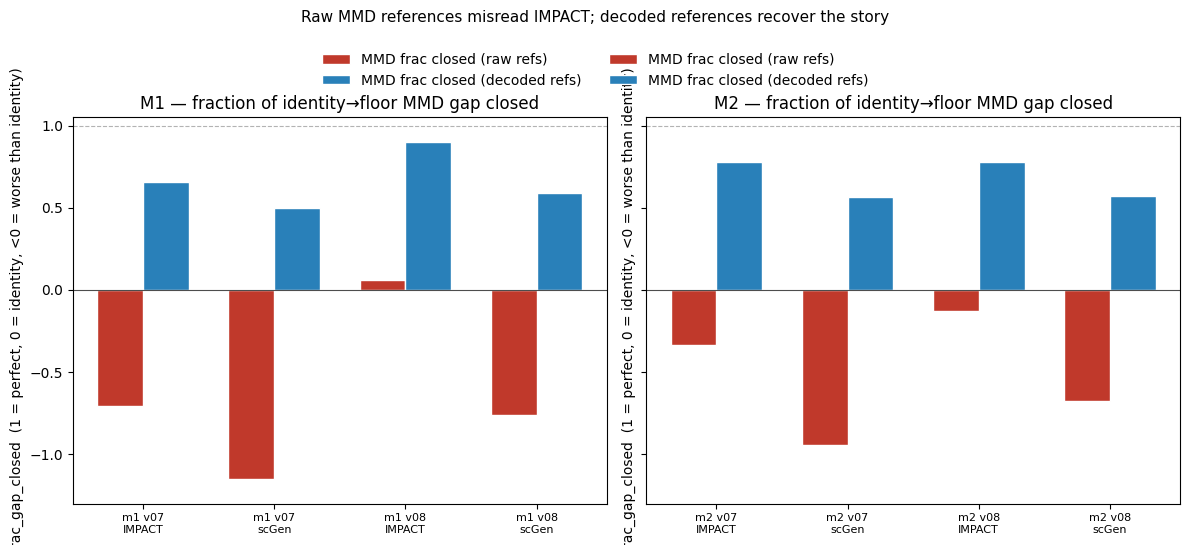

wrote fig2_r2_frac_closed_raw_vs_decoded.png / .pdf


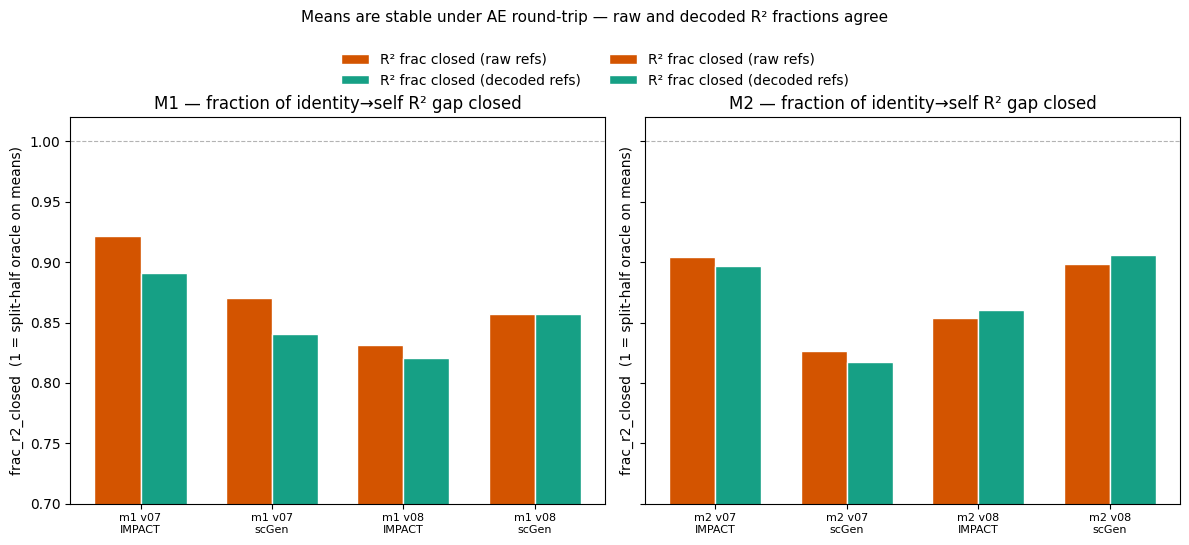

wrote fig3_raw_mmd_frac_vs_r2_frac.png / .pdf


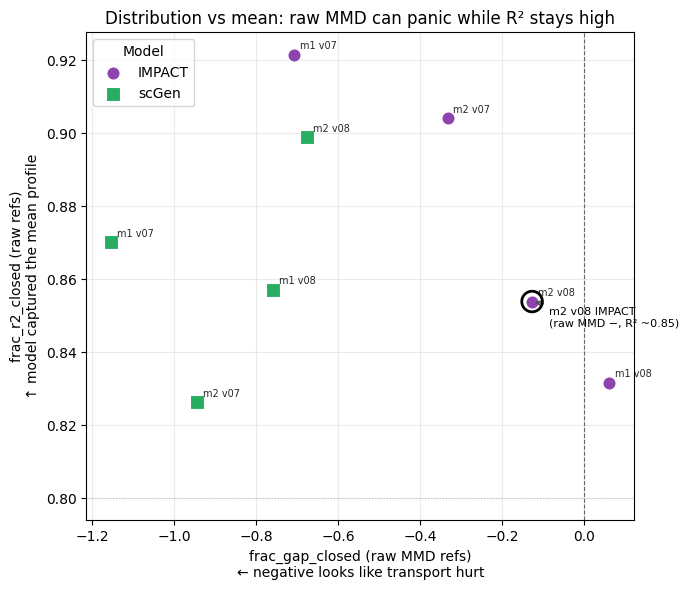

wrote fig4_m1_impact_v07_v08_cleanup.png / .pdf


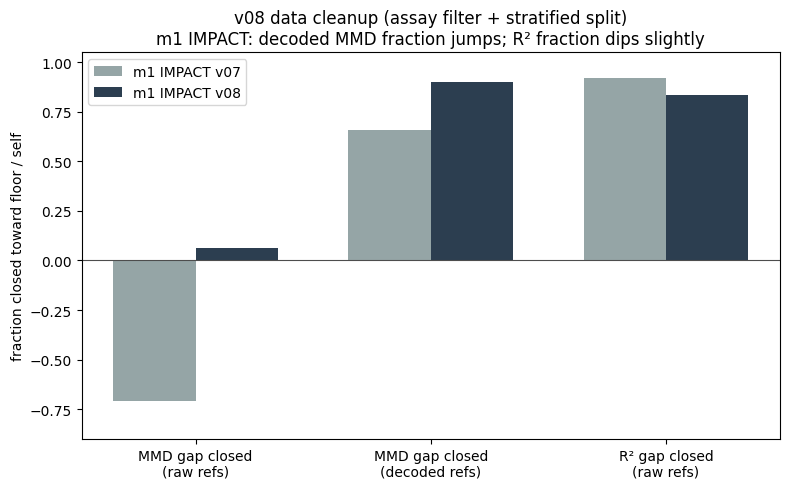

wrote fig5_m1_v08_impact_mmd_ladder.png / .pdf


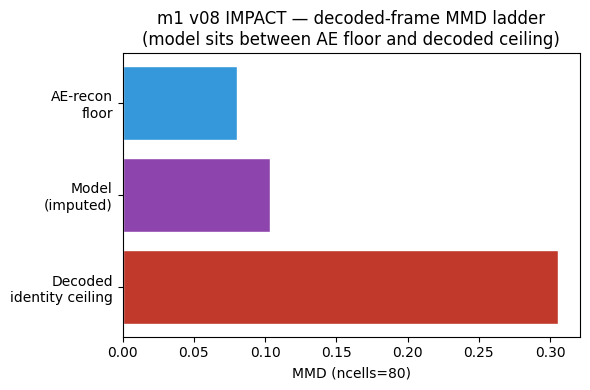

All figures in: /n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/speciesOT/baseline/analysis/v08_figure_outputs


In [6]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

FIG_DIR = REPO / "speciesOT/baseline/analysis/v08_figure_outputs"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Prefer in-memory dual; fall back to CSV if §2 not run yet.
if "dual" not in dir() or dual is None:
    dual = pd.read_csv(REPO / "speciesOT/baseline/analysis/v08_scorecard_dual.csv")

plot_df = dual.copy()
plot_df[["line", "ver", "method"]] = plot_df["model"].str.extract(
    r"^(m1|m2|atlas-CD8)\s+(v07|v08)\s+(IMPACT|scGen)$"
)
# Main mentor story: capped monocyte holdouts with full sidecars
core = plot_df[plot_df["line"].isin(["m1", "m2"]) & (plot_df["dec_status"] == "ok")].copy()
core = core.sort_values(["line", "ver", "method"])
core["label"] = core["line"] + " " + core["ver"] + "\n" + core["method"]

RAW_C = "#c0392b"
DEC_C = "#2980b9"
IMPACT_C = "#8e44ad"
SCGEN_C = "#27ae60"


def _save(fig, stem):
    fig.savefig(FIG_DIR / f"{stem}.png", dpi=200, bbox_inches="tight")
    fig.savefig(FIG_DIR / f"{stem}.pdf", bbox_inches="tight")
    print(f"wrote {stem}.png / .pdf")


# --- Fig 1: MMD fraction closed (raw vs decoded) --------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, line in zip(axes, ["m1", "m2"]):
    sub = core[core["line"] == line]
    x = np.arange(len(sub))
    w = 0.35
    ax.bar(x - w / 2, sub["frac_gap_closed_raw"], w, label="MMD frac closed (raw refs)",
           color=RAW_C, edgecolor="white")
    ax.bar(x + w / 2, sub["frac_gap_closed_decoded"], w, label="MMD frac closed (decoded refs)",
           color=DEC_C, edgecolor="white")
    ax.axhline(0, color="0.3", lw=0.8)
    ax.axhline(1, color="0.7", ls="--", lw=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(sub["label"], fontsize=8)
    ax.set_title(f"{line.upper()} — fraction of identity→floor MMD gap closed")
    ax.set_ylabel("frac_gap_closed  (1 = perfect, 0 = identity, <0 = worse than identity)")
    ax.set_ylim(-1.3, 1.05)
fig.legend(loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.02), frameon=False)
fig.suptitle("Raw MMD references misread IMPACT; decoded references recover the story",
             fontsize=11, y=1.08)
fig.tight_layout()
_save(fig, "fig1_mmd_frac_gap_raw_vs_decoded")
plt.show()


# --- Fig 2: R² fraction closed (raw vs decoded) ---------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, line in zip(axes, ["m1", "m2"]):
    sub = core[core["line"] == line]
    x = np.arange(len(sub))
    w = 0.35
    ax.bar(x - w / 2, sub["frac_r2_closed_raw"], w, label="R² frac closed (raw refs)",
           color="#d35400", edgecolor="white")
    ax.bar(x + w / 2, sub["frac_r2_closed_decoded"], w, label="R² frac closed (decoded refs)",
           color="#16a085", edgecolor="white")
    ax.axhline(1, color="0.7", ls="--", lw=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(sub["label"], fontsize=8)
    ax.set_title(f"{line.upper()} — fraction of identity→self R² gap closed")
    ax.set_ylabel("frac_r2_closed  (1 = split-half oracle on means)")
    ax.set_ylim(0.7, 1.02)
fig.legend(loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.02), frameon=False)
fig.suptitle("Means are stable under AE round-trip — raw and decoded R² fractions agree",
             fontsize=11, y=1.08)
fig.tight_layout()
_save(fig, "fig2_r2_frac_closed_raw_vs_decoded")
plt.show()


# --- Fig 3: scatter — raw MMD fraction vs R² fraction -------------------------
fig, ax = plt.subplots(figsize=(7, 6))
for method, color, marker in [("IMPACT", IMPACT_C, "o"), ("scGen", SCGEN_C, "s")]:
    sub = core[core["method"] == method]
    ax.scatter(sub["frac_gap_closed_raw"], sub["frac_r2_closed_raw"],
               c=color, marker=marker, s=90, edgecolors="white", linewidths=0.8, label=method, zorder=3)
    for _, r in sub.iterrows():
        ax.annotate(r["line"] + " " + r["ver"], (r["frac_gap_closed_raw"], r["frac_r2_closed_raw"]),
                    textcoords="offset points", xytext=(4, 4), fontsize=7, alpha=0.85)
ax.axvline(0, color="0.4", ls="--", lw=0.8)
ax.axhline(0.8, color="0.75", ls=":", lw=0.8)
ax.set_xlabel("frac_gap_closed (raw MMD refs)\n← negative looks like transport hurt")
ax.set_ylabel("frac_r2_closed (raw refs)\n↑ model captured the mean profile")
ax.set_title("Distribution vs mean: raw MMD can panic while R² stays high")
ax.legend(title="Model")
ax.grid(True, alpha=0.25)
# highlight canonical example
ex = core[(core["line"] == "m2") & (core["ver"] == "v08") & (core["method"] == "IMPACT")]
if len(ex):
    ax.scatter(ex["frac_gap_closed_raw"], ex["frac_r2_closed_raw"], s=220, facecolors="none",
               edgecolors="black", linewidths=2, zorder=4)
    ax.annotate("m2 v08 IMPACT\n(raw MMD −, R² ~0.85)", ex.iloc[0][["frac_gap_closed_raw", "frac_r2_closed_raw"]].values,
                textcoords="offset points", xytext=(12, -18), fontsize=8,
                arrowprops=dict(arrowstyle="->", color="0.3"))
fig.tight_layout()
_save(fig, "fig3_raw_mmd_frac_vs_r2_frac")
plt.show()


# --- Fig 4: m1 IMPACT v07 → v08 cleanup slide ---------------------------------
slide = core[(core["line"] == "m1") & (core["method"] == "IMPACT")].sort_values("ver")
if len(slide) == 2:
    metrics = [
        ("frac_gap_closed_raw", "MMD gap closed\n(raw refs)", RAW_C),
        ("frac_gap_closed_decoded", "MMD gap closed\n(decoded refs)", DEC_C),
        ("frac_r2_closed_raw", "R² gap closed\n(raw refs)", "#d35400"),
    ]
    fig, ax = plt.subplots(figsize=(8, 5))
    x = np.arange(len(metrics))
    w = 0.35
    v07 = slide[slide["ver"] == "v07"].iloc[0]
    v08 = slide[slide["ver"] == "v08"].iloc[0]
    ax.bar(x - w / 2, [v07[m] for m, _, _ in metrics], w, label="m1 IMPACT v07", color="#95a5a6")
    ax.bar(x + w / 2, [v08[m] for m, _, _ in metrics], w, label="m1 IMPACT v08", color="#2c3e50")
    ax.axhline(0, color="0.3", lw=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([lab for _, lab, _ in metrics])
    ax.set_ylabel("fraction closed toward floor / self")
    ax.set_title("v08 data cleanup (assay filter + stratified split)\nm1 IMPACT: decoded MMD fraction jumps; R² fraction dips slightly")
    ax.legend()
    ax.set_ylim(-0.9, 1.05)
    fig.tight_layout()
    _save(fig, "fig4_m1_impact_v07_v08_cleanup")
    plt.show()


# --- Fig 5: decoded MMD reference ladder (m1 v08 IMPACT) ------------------------
ex = core[(core["line"] == "m1") & (core["ver"] == "v08") & (core["method"] == "IMPACT")]
if len(ex):
    r = ex.iloc[0]
    refs = ["AE-recon\nfloor", "Model\n(imputed)", "Decoded\nidentity ceiling"]
    vals = [r["mmd_ae_recon_floor"], r["MMD"], r["mmd_decoded_ceiling"]]
    cols = ["#3498db", IMPACT_C, RAW_C]
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.barh(refs, vals, color=cols, edgecolor="white")
    ax.set_xlabel("MMD (ncells=80)")
    ax.set_title("m1 v08 IMPACT — decoded-frame MMD ladder\n(model sits between AE floor and decoded ceiling)")
    ax.invert_yaxis()
    fig.tight_layout()
    _save(fig, "fig5_m1_v08_impact_mmd_ladder")
    plt.show()

print("All figures in:", FIG_DIR)

In [ ]:
# run_id                          mode   fgc_dec   fr2_dec   mean_js   fgc_raw   R^2
# a_uncapped_v08_ood/impact       ood    0.935     0.846     0.451     -0.247    0.921
# m1_v08_ood/impact               ood    0.897     0.821     0.449     +0.061    0.919
# m2_v08_ood/impact               ood    0.776     0.861     0.451     -0.128    0.923

fgc_dec = frac_gap_closed_decoded — the north-star. Fraction of the mouse→human MMD (full-distribution) gap the model closes, measured in the AE-decoded frame (apples-to-apples). Scale: 1.0 = perfect (reached the best achievable at this sample size), 0.0 = no better than untransported mouse, negative = genuine overshoot. So a_uncapped at 0.935 closes ~94% of the distributional gap — your best cut.

fr2_dec = frac_r2_closed_decoded — the mean-based guardrail. Same idea but on per-gene mean expression instead of the full distribution. "Did it get the average expression right?" 0.821–0.861 here = yes, captures ~82–86% of the mean gap. Read it alongside fgc_dec: high on both = the model got both the average and the spread right.

mean_js = mean per-gene Jensen-Shannon divergence (a symmetric, bounded version of KL divergence — your mentor's "KL" check). It's a distance, so lower is better (0 = identical marginals). All three sit at ~0.45, meaning per-gene marginals are comparably off across cuts — a lead worth chasing later. Note this one is computed in the raw frame, so treat it as relative-across-runs, not absolute.

fgc_raw = frac_gap_closed in the raw frame — kept only as a diagnostic, do not rank on it. This is the artifact that caused all your confusion: it compares the decoded prediction against raw references (apples-to-oranges), so it goes negative (-0.247, -0.128) even when the model is excellent. Compare fgc_raw = -0.247 vs fgc_dec = 0.935 for a_uncapped — same model, same data; the only difference is an honest vs dishonest measurement frame. That gap is the AE round-trip tax made numeric.

R^2 — R²-of-means (squared Pearson r between predicted and real human mean expression vectors). A simple, AE-robust "is the average right" sanity number. All ~0.92, consistent with fr2_dec.

